# 02 — Preprocessing & Split Dataset
- Mapping CDD subfolder → 6 kelas
- Validasi integritas gambar
- Split stratifikasi 70/15/15
- Copy ke `dataset/processed/train`, `val`, `test`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.config import RAW_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, CLASS_MAPPING
from src.dataset import scan_raw_dataset, split_dataset, prepare_splits
from src.preprocessing import validate_images
from src.utils import print_class_distribution, class_distribution
import pandas as pd
print('Setup OK')

✅ Config loaded successfully!
📁 RAW_DIR: C:\Users\ACER\Documents\ANALIS CITRA.py\dataset\raw\Comprehensive Disaster Dataset(CDD)
📁 TRAIN_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\train
📁 VAL_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\val
📁 TEST_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\test
📊 Classes: ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
📐 Input Shape: (224, 224, 3)
🔄 FREEZE_EPOCHS: 10
🔄 FINETUNE_EPOCHS: 10
Setup OK


## 1. Pemetaan Kelas CDD

In [2]:
df_map = pd.DataFrame([
    {'Subfolder CDD': k, 'Label Kelas': v}
    for k, v in CLASS_MAPPING.items()
])
print(df_map.to_string(index=False))

         Subfolder CDD            Label Kelas
Damaged_Infrastructure Damaged_Infrastructure
         Fire_Disaster          Fire_Disaster
          Human_Damage           Human_Damage
         Land_Disaster          Land_Disaster
            Non_Damage             Non_Damage
        Water_Disaster         Water_Disaster


## 2. Scan Raw Dataset (Rekursif)

`os.walk()` dipakai agar subfolder berlapis seperti `Damaged_Infrastructure/Earthquake` ikut terbaca.

In [3]:
# Scan REKURSIF — masuk ke semua subfolder
label_paths = scan_raw_dataset(RAW_DIR)

dist_raw = {k: len(v) for k, v in label_paths.items()}
print_class_distribution(dist_raw, 'Distribusi Raw Dataset (Rekursif)')

df_raw = pd.DataFrame([
    {'Kelas': k, 'Jumlah': v, '%': round(v/sum(dist_raw.values())*100, 2)}
    for k, v in sorted(dist_raw.items())
])
df_raw.loc[len(df_raw)] = ['TOTAL', sum(dist_raw.values()), 100.0]
print(df_raw.to_string(index=False))

[SCAN] Damaged_Infrastructure              → Damaged_Infrastructure    (1454 gambar)
[SCAN] Fire_Disaster                       → Fire_Disaster             (933 gambar)
[SCAN] Human_Damage                        → Human_Damage              (241 gambar)
[SCAN] Land_Disaster                       → Land_Disaster             (657 gambar)
[SCAN] Non_Damage                          → Non_Damage                (9237 gambar)
[SCAN] Water_Disaster                      → Water_Disaster            (1035 gambar)

  Distribusi Raw Dataset (Rekursif)
  Damaged_Infrastructure  1454  ███
  Fire_Disaster          933  ██
  Human_Damage           241  
  Land_Disaster          657  █
  Non_Damage            9237  ████████████████████
  Water_Disaster        1035  ██
  TOTAL                13557

                 Kelas  Jumlah      %
Damaged_Infrastructure    1454  10.73
         Fire_Disaster     933   6.88
          Human_Damage     241   1.78
         Land_Disaster     657   4.85
            Non_Dama

## 3. Validasi Integritas Gambar

In [4]:
print('Memeriksa integritas gambar di RAW_DIR ...')
broken = validate_images(RAW_DIR)
if broken:
    print(f'Ditemukan {len(broken)} gambar rusak:')
    for b in broken:
        print(' -', b)
    print('\n⚠️ Gambar rusak akan dilewati saat copy.')
else:
    print('✅ Semua gambar valid!')

Memeriksa integritas gambar di RAW_DIR ...
Ditemukan 1 gambar rusak:
 - C:\Users\ACER\Documents\ANALIS CITRA.py\dataset\raw\Comprehensive Disaster Dataset(CDD)\Human_Damage\02_0069.png

⚠️ Gambar rusak akan dilewati saat copy.


## 4. Split Dataset (70 / 15 / 15)

In [5]:
train_d, val_d, test_d = split_dataset(label_paths)

rows = []
for cls in sorted(label_paths.keys()):
    t  = len(train_d.get(cls, []))
    v  = len(val_d.get(cls, []))
    te = len(test_d.get(cls, []))
    rows.append({'Kelas': cls, 'Train': t, 'Validation': v, 'Test': te, 'Total': t+v+te})

df_split = pd.DataFrame(rows)
total_row = {'Kelas': 'TOTAL',
             'Train': df_split['Train'].sum(),
             'Validation': df_split['Validation'].sum(),
             'Test': df_split['Test'].sum(),
             'Total': df_split['Total'].sum()}
df_split = pd.concat([df_split, pd.DataFrame([total_row])], ignore_index=True)
print(df_split.to_string(index=False))

                 Kelas  Train  Validation  Test  Total
Damaged_Infrastructure   1017         218   219   1454
         Fire_Disaster    653         139   141    933
          Human_Damage    168          36    37    241
         Land_Disaster    459          98   100    657
            Non_Damage   6465        1385  1387   9237
        Water_Disaster    724         155   156   1035
                 TOTAL   9486        2031  2040  13557


## 5. Copy File ke Folder Split

> **⚠️ Jalankan sekali saja!** Set `overwrite=True` hanya jika ingin reset ulang.
> Proses copy ~13.557 file membutuhkan waktu **5–15 menit**.

In [6]:
prepare_splits(overwrite=False)
print('\n✅ Split selesai!')

[INFO] Folder split sudah ada. Gunakan overwrite=True untuk reset.

✅ Split selesai!


## 6. Verifikasi Hasil Split

Verifikasi jumlah file di folder processed:


  Train
  Damaged_Infrastructure  1017  ███
  Fire_Disaster          653  ██
  Human_Damage           168  
  Land_Disaster          459  █
  Non_Damage            6465  ████████████████████
  Water_Disaster         724  ██
  TOTAL                 9486


  Validation
  Damaged_Infrastructure   218  ███
  Fire_Disaster          139  ██
  Human_Damage            36  
  Land_Disaster           98  █
  Non_Damage            1385  ████████████████████
  Water_Disaster         155  ██
  TOTAL                 2031


  Test
  Damaged_Infrastructure   219  ███
  Fire_Disaster          141  ██
  Human_Damage            37  
  Land_Disaster          100  █
  Non_Damage            1387  ████████████████████
  Water_Disaster         156  ██
  TOTAL                 2040



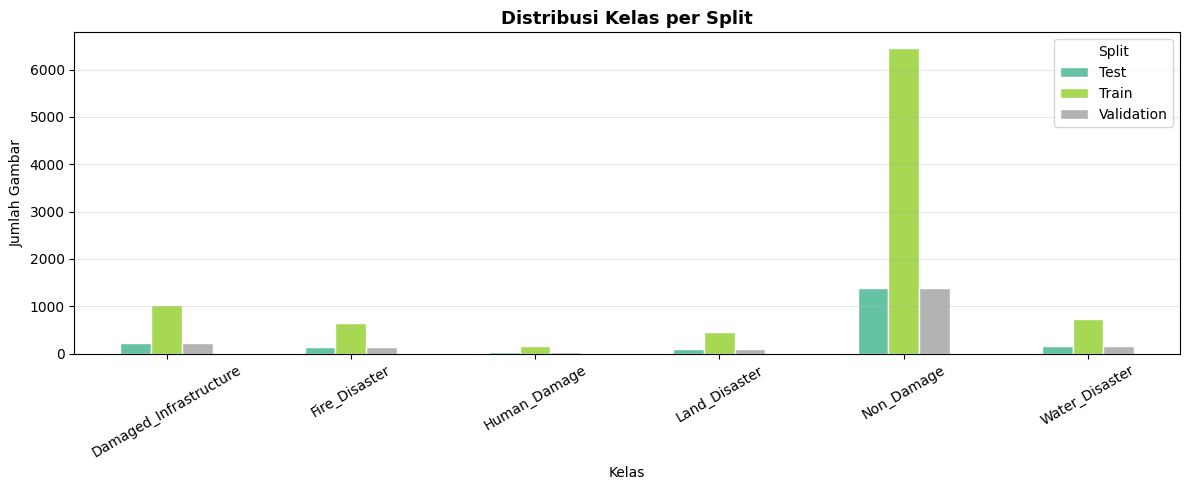


[saved] results/eda/split_distribution.png


In [7]:
print('Verifikasi jumlah file di folder processed:\n')
rows_ver = []
for split_name, split_dir in [('Train', TRAIN_DIR), ('Validation', VAL_DIR), ('Test', TEST_DIR)]:
    if not os.path.isdir(split_dir):
        print(f'❌ {split_name}: folder tidak ditemukan ({split_dir})')
        continue
    d = class_distribution(split_dir)
    for cls, n in d.items():
        rows_ver.append({'Split': split_name, 'Kelas': cls, 'Jumlah': n})
    print_class_distribution(d, split_name)

if rows_ver:
    import matplotlib.pyplot as plt
    import seaborn as sns
    df_ver = pd.DataFrame(rows_ver)
    fig, ax = plt.subplots(figsize=(12, 5))
    pivot = df_ver.pivot(index='Kelas', columns='Split', values='Jumlah')
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title('Distribusi Kelas per Split', fontweight='bold', fontsize=13)
    ax.set_xlabel('Kelas')
    ax.set_ylabel('Jumlah Gambar')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Split')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    os.makedirs('../results/eda', exist_ok=True)
    plt.savefig('../results/eda/split_distribution.png', dpi=150)
    plt.show()
    print('\n[saved] results/eda/split_distribution.png')

---
### ✅ Preprocessing & Split selesai.

**Hasil split:**
- Train: 9.486 gambar (70%)
- Validation: 2.031 gambar (15%)
- Test: 2.040 gambar (15%)
- **Total: 13.557 gambar**

Lanjut ke `03_Model_Training.ipynb`